# Cell Voltage Exploratory Data Analysis 
**Date:** 2026-03-03 | **Session duration:** 14 min | **Pack:** 84-cell 
## Summary
Pack behavior appears healthy overall, though several cells warrant closer monitoring. 
See conclusions for details.

**Imports & Configs**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PATH = 'data/cellvoltages_2026-03-03-21-21-48.csv'
N_CELLS = 84

lsu_colors = ["#4E2A84", "#FDD023","#7F857765","#000000"]  # purple, gold, gray, black
sns.set_theme(style='darkgrid') 
sns.set_palette(sns.color_palette(lsu_colors))
plt.rcParams['figure.figsize'] = (14, 4)

**Dataframe Cleaning**

In [2]:
df = pd.read_csv(PATH)
df.columns = df.columns.str.strip()

DROP_COLS = ([f'Cell Resistance {i}' for i in range(1, N_CELLS + 1)] + 
             [f'Open Cell Voltage {i}' for i in range(1, N_CELLS + 1)]) # Impedance Analysis TBA

CV_COLS = [f'Cell Voltage {i}' for i in range(1, N_CELLS + 1)] # Cell Voltage Columns

df = df.drop(columns=DROP_COLS)
df = df.dropna(axis=1, how='all') #Delete BMS trailing comma
df.columns = df.columns.str.strip()

df['Time'] = pd.to_datetime(df['Time'].str.replace(r'\s+CST\s+', ' ', regex=True), 
                             format='%a %b %d %H:%M:%S %Y')

df['elapsed_s'] = (df['Time'] - df['Time'].iloc[0]).dt.total_seconds()

print(df.isnull().sum().sum(), 'total missing values')

0 total missing values


**Pack Data Overview**

In [3]:
print(f'Duration: {df["elapsed_s"].max() / 60:.1f} min')
print(df.shape)
df.head()

Duration: 14.0 min
(1807, 100)


,Time,State of Charge,Pack Voltage,Pack Current,Pack CCL,Pack DCL,Highest Cell ID,Highest Cell Volt,Lowest Cell ID,Lowest Cell Volt,...,Cell Voltage 76,Cell Voltage 77,Cell Voltage 78,Cell Voltage 79,Cell Voltage 80,Cell Voltage 81,Cell Voltage 82,Cell Voltage 83,Cell Voltage 84,elapsed_s
0,2026-03-03 21:21:53,50.0,296.9,0.2,6,198,14,3.5380,9,3.5056,...,3.5372,3.5356,3.5363,3.5349,3.5366,3.5339,3.5360,3.5349,3.5334,0.0
1,2026-03-03 21:21:54,50.0,296.8,0.0,6,198,14,3.5381,9,3.5055,...,3.5372,3.5356,3.5363,3.5349,3.5366,3.5339,3.5360,3.5349,3.5334,1.0
2,2026-03-03 21:21:54,50.0,296.8,-0.3,6,198,14,3.5381,9,3.5055,...,3.5371,3.5356,3.5363,3.5348,3.5367,3.5339,3.5360,3.5350,3.5333,1.0
3,2026-03-03 21:21:54,50.0,296.8,-0.3,6,198,14,3.5380,9,3.5055,...,3.5372,3.5356,3.5363,3.5348,3.5367,3.5339,3.5361,3.5349,3.5334,1.0
4,2026-03-03 21:21:55,50.0,296.8,-0.3,6,198,14,3.5381,9,3.5055,...,3.5371,3.5357,3.5363,3.5349,3.5368,3.5339,3.5360,3.5349,3.5333,2.0


**Pack Current & Voltage Over Time**

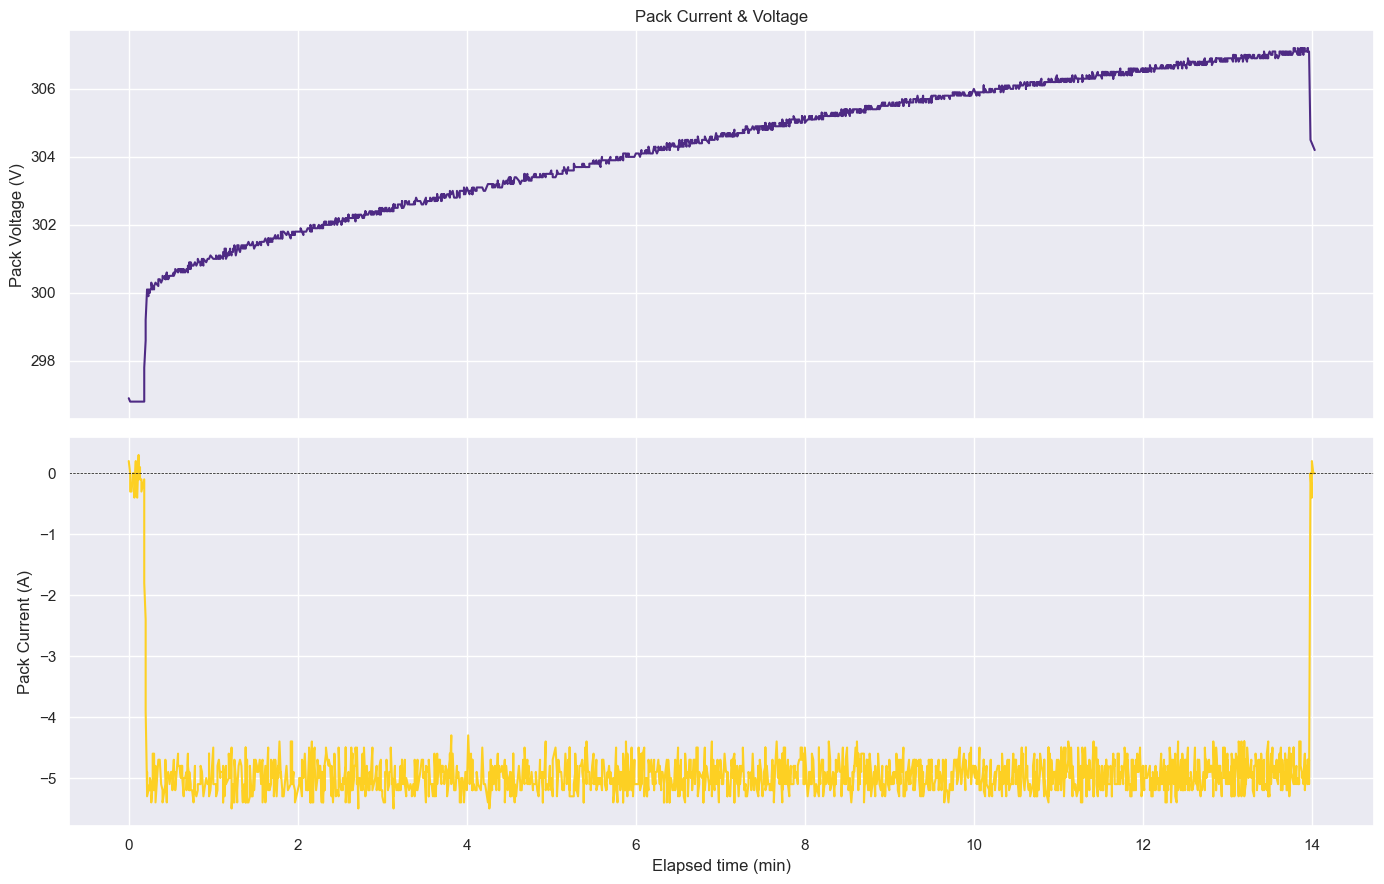

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

axes[0].plot(df['elapsed_s'] / 60, df['Pack Voltage'])
axes[0].set_ylabel('Pack Voltage (V)')
axes[0].set_title('Pack Current & Voltage')

axes[1].plot(df['elapsed_s'] / 60, df['Pack Current'], color = '#FDD023')
axes[1].axhline(0, color='black', linewidth=0.5, linestyle='--')
axes[1].set_ylabel('Pack Current (A)')
axes[1].set_xlabel('Elapsed time (min)')

plt.tight_layout()
plt.show()

**Voltage Spread Over Time**

C:\Users\randl\AppData\Local\Temp\ipykernel_36292\2168823553.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']


Text(0.5, 0, 'Elapsed time (min)')

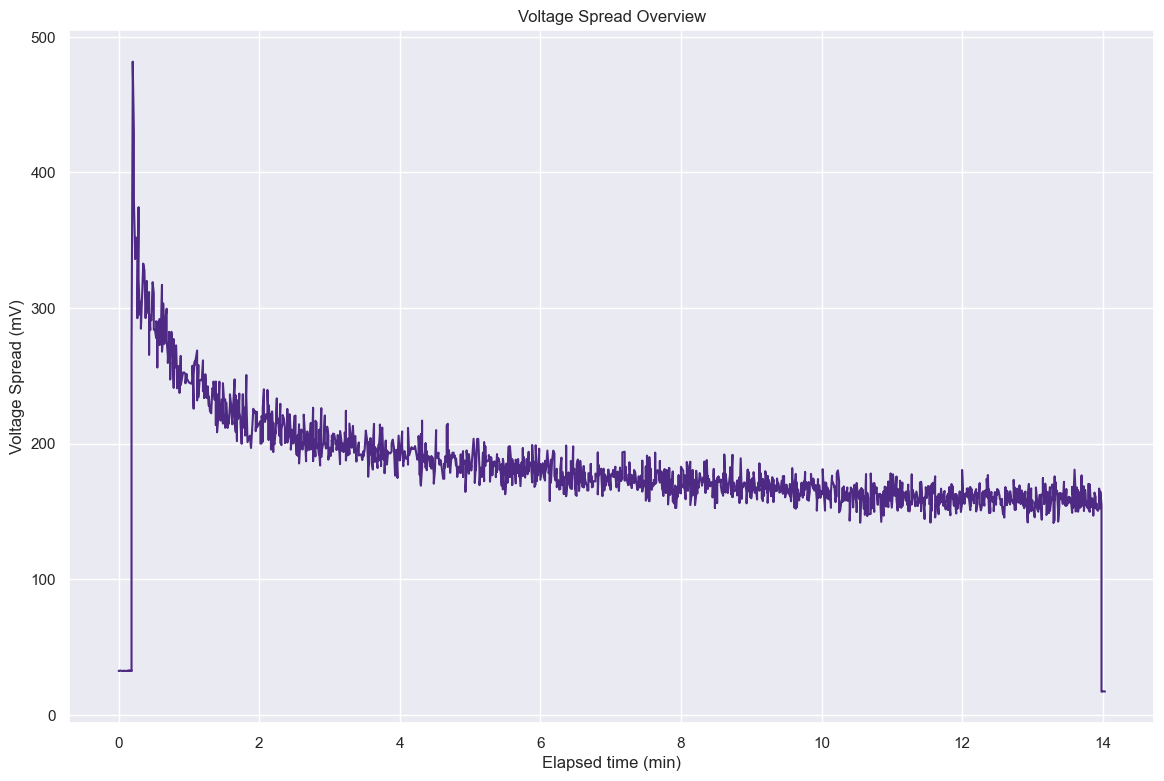

In [5]:
df['Voltage Spread'] = df['Highest Cell Volt'] - df['Lowest Cell Volt']

fig,ax = plt.subplots(1, 1, figsize=(14, 9))
ax.plot(df['elapsed_s'] / 60, df['Voltage Spread'] * 1000)
ax.set_title('Voltage Spread Overview')
ax.set_ylabel('Voltage Spread (mV)')
ax.set_xlabel('Elapsed time (min)')


**Mean Voltage And Mean Rank Per Cell**

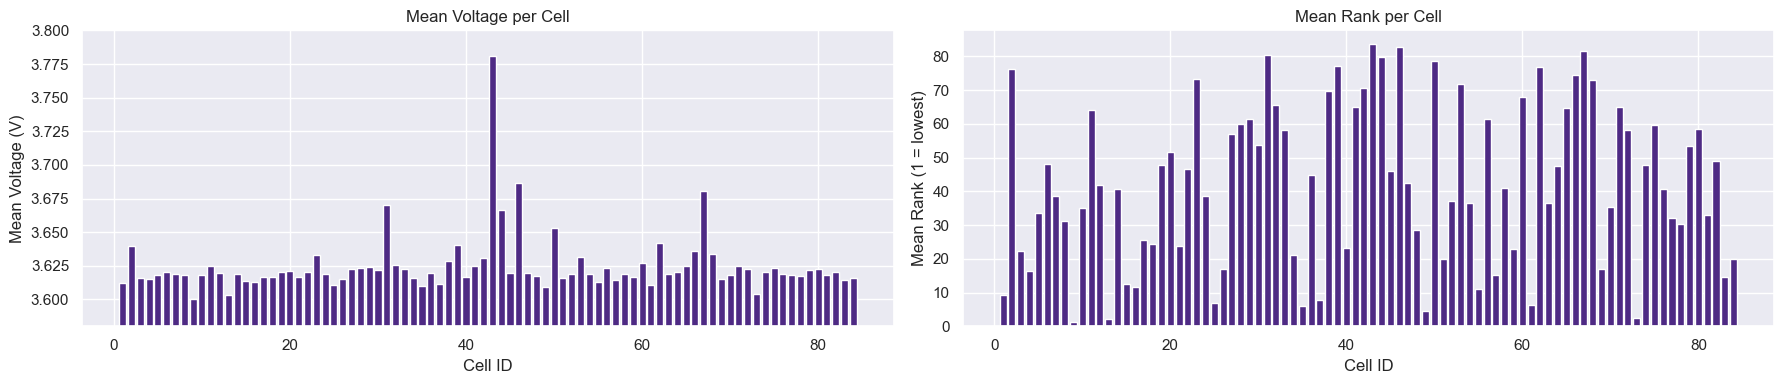

In [6]:
CV_COLS_NUMS = range(1, N_CELLS + 1)
cell_mean_voltage = df[CV_COLS].mean()
cell_mean_rank = df[CV_COLS].rank(axis=1).mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))

ax1.bar(CV_COLS_NUMS, cell_mean_voltage)
ax1.set_ylim(3.58, 3.8)
ax1.set_title('Mean Voltage per Cell')
ax1.set_xlabel('Cell ID')
ax1.set_ylabel('Mean Voltage (V)')

ax2.bar(CV_COLS_NUMS, cell_mean_rank)
ax2.set_title('Mean Rank per Cell')
ax2.set_xlabel('Cell ID')
ax2.set_ylabel('Mean Rank (1 = lowest)')

plt.tight_layout()
plt.show()

**Mean Cell Rank Distribution**

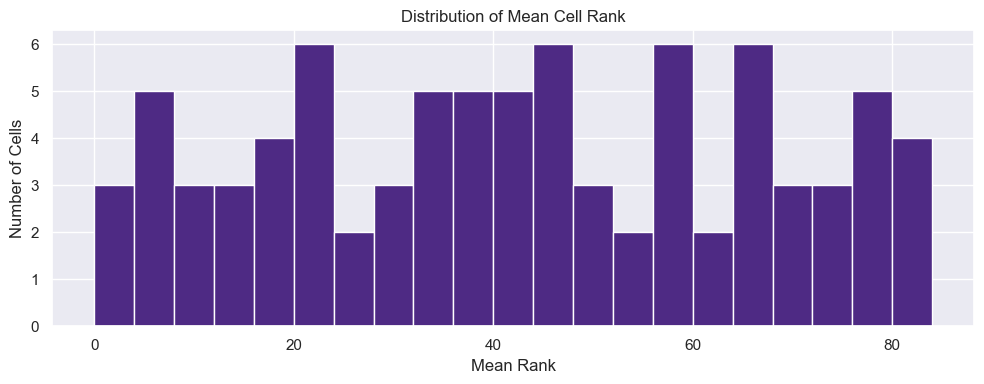

In [7]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cell_mean_rank, bins=range(0, 85, 4))
ax.set_title('Distribution of Mean Cell Rank')
ax.set_xlabel('Mean Rank')
ax.set_ylabel('Number of Cells')

plt.tight_layout()
plt.show()

**Cell Voltage By Z-Score (Std Deviations From 0)**

Cell Voltage 9    -1.097246
Cell Voltage 13   -0.936576
Cell Voltage 73   -0.919080
Cell Voltage 49   -0.694912
Cell Voltage 35   -0.667868
dtype: float64
Cell Voltage 43    6.911266
Cell Voltage 46    2.751706
Cell Voltage 67    2.476754
dtype: float64


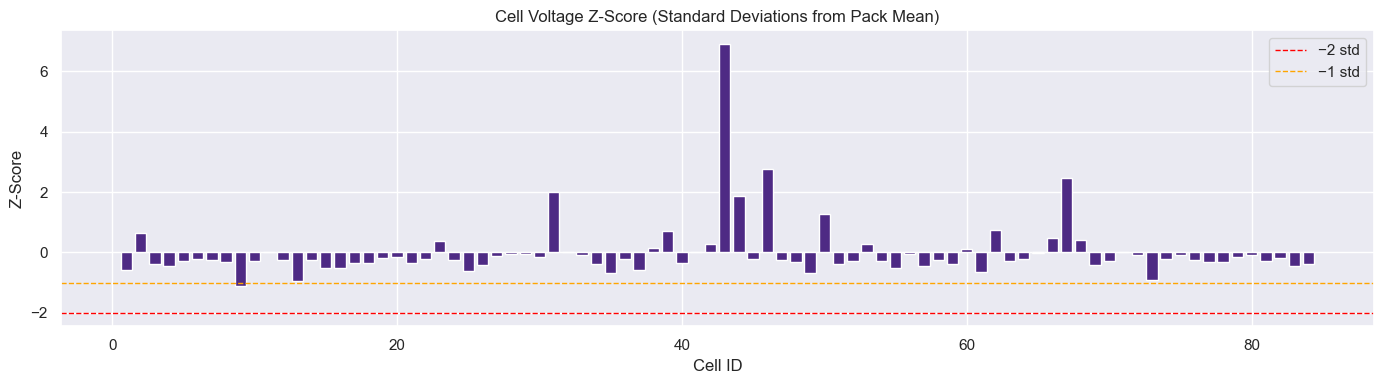

In [8]:
pack_mean_voltage = cell_mean_voltage.mean()
pack_std_voltage = cell_mean_voltage.std()

z_scores = (cell_mean_voltage - pack_mean_voltage) / pack_std_voltage

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(1, N_CELLS + 1), z_scores)
ax.axhline(-2, color='red', linestyle='--', linewidth=1, label='−2 std')
ax.axhline(-1, color='orange', linestyle='--', linewidth=1, label='−1 std')
ax.set_title('Cell Voltage Z-Score (Standard Deviations from Pack Mean)')
ax.set_xlabel('Cell ID')
ax.set_ylabel('Z-Score')
ax.legend()

plt.tight_layout()
print(z_scores.nsmallest(5))
print(z_scores.nlargest(3))
plt.show()


**Voltage Of Special Cells Vs Pack Mean Voltage**

Mean Voltage of Weakest Cells (V)
Cell Voltage 9     3.599978
Cell Voltage 13    3.603605
Cell Voltage 73    3.604000
Cell Voltage 49    3.609060
Cell Voltage 35    3.609671
dtype: float64
Mean Rank of Weakest Cells (1-84)
Cell Voltage 9     1.397067
Cell Voltage 13    2.119258
Cell Voltage 73    2.523520
Cell Voltage 49    4.510515
Cell Voltage 35    5.919203
dtype: float64


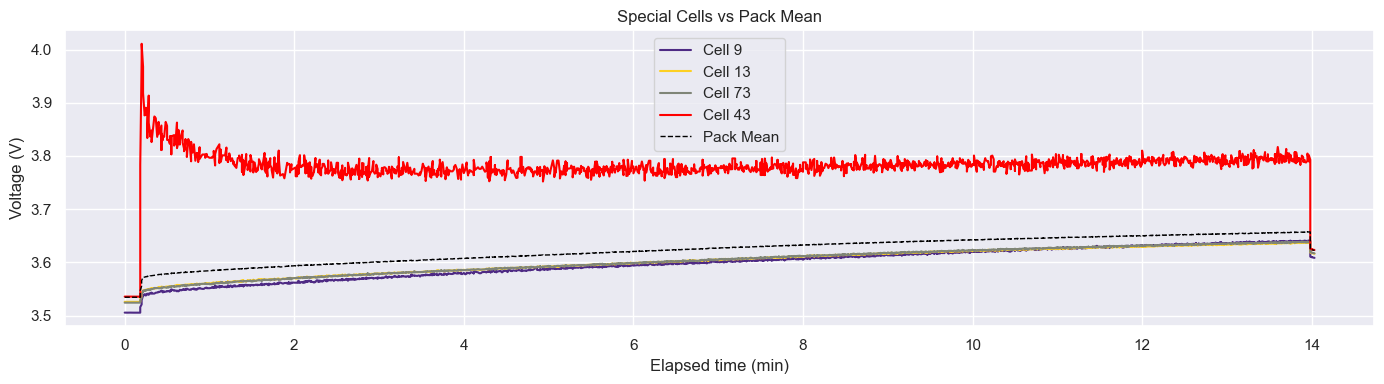

In [9]:
print("Mean Voltage of Weakest Cells (V)")
print(cell_mean_voltage.nsmallest(5))
print("Mean Rank of Weakest Cells (1-84)")
print(cell_mean_rank.nsmallest(5))

pack_mean = df[CV_COLS].mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df['elapsed_s'] / 60, df['Cell Voltage 9'],  label='Cell 9')
ax.plot(df['elapsed_s'] / 60, df['Cell Voltage 13'], label='Cell 13')
ax.plot(df['elapsed_s'] / 60, df['Cell Voltage 73'], label='Cell 73')
ax.plot(df['elapsed_s'] / 60, df['Cell Voltage 43'], label='Cell 43', color='red') # anomalous above mean voltage
ax.plot(df['elapsed_s'] / 60, pack_mean, label='Pack Mean', color='black', linestyle='--', linewidth=1)
ax.set_title('Special Cells vs Pack Mean')
ax.set_xlabel('Elapsed time (min)')
ax.set_ylabel('Voltage (V)')
ax.legend()

plt.tight_layout()
plt.show()

## Conclusion
### **Pack Health Overview**
The pack charges cleanly with narrowing cell voltage spread over time, indicating healthy balancing. The distribution of mean cell ranks is roughly uniform, suggesting that weak performance of specific cells is not a very large concern as of now.
### **Cell 43**
 However, cell 43 registered as 6.9 standard deviations away from pack mean when z-score analysis of each cell was run across all cells. Upon further inspection, cell 43 voltage registers as high as 4.0 volts and remains consistently and significantly above the pack mean. Suspected causes could be that cell 43 is being overcharged initially or it has lower capacity and hits higher voltage faster. This suggests that cell 43 may be more likely to degrade in the future and is statistically significant enough to warrant further analysis. 
### **Cells 9,13, 73**
 While the mean voltages of cells 9, 13, and 73 underperform the pack mean voltage by about 20–35mV, this amounts to only about one standard deviation away from the pack mean voltage. 
### **Notes & Next Steps**
**Note:** A single 14-minute charging session is insufficient to draw firm conclusions, though cell 43's behavior is anomalous enough to warrant immediate attention regardless.

**Next steps:** Re-run this notebook on future session exports to track whether the same 
cells consistently underperform before taking any action. Cell 43 should be monitored closely. If it continues to register significantly above pack mean across future sessions, it should be escalated to senior team members for evaluation.